# Analyzing KMeans Model Results

## Setup

In [1]:
# Load Dependencies
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
from pathlib import Path
from scipy import stats
from scipy.stats import pearsonr
import statsmodels.formula.api as smf
from pathlib import Path
from sklearn.preprocessing import StandardScaler

In [2]:
# Establish BASE_DIR
try:
    BASE_DIR = Path.cwd().parent.parent
    print(f"Success! BASE_DIR is: {BASE_DIR}")
except Exception as e:
    print(f"Still failing. Current location: {Path.cwd()}")
    print(f"Error details: {e}")

Success! BASE_DIR is: /Users/amberteetsel/MSDS/DataMining/substance-abuse-predictions


In [3]:
# Pre-Defined labels, colors

# Define text labels for clusters
clustering_map = {
    0: 'Moderate Risk (Economic Protections)', # Higher wage, moderate deaths
    1: 'High Risk (Prescription-Driven)',      # Extreme Oxy levels
    2: 'Low Risk',                              # Negative values across the board
    3: 'Acute High Risk (Fentanyl-Driven)'      # Extreme Fentanyl levels
}

# color palette for clusters
color_discrete_map = {
    'Low Risk': '#2ecc71',                    # Green
    'Moderate Risk': '#f1c40f',               # Yellow
    'High Risk (Prescription-Driven)': '#e67e22', # Orange
    'Acute High Risk (Fentanyl-Driven)': '#e74c3c' # Red
}

pal = {
    'Moderate Risk': '#f1c40f', 
    'High Risk (Prescription-Driven)': '#e67e22'
}

# mapping labels
label_order = {
    'Low Risk': 0, 
    'Moderate Risk': 1, 
    'High Risk (Prescription-Driven)': 2, 
    'Acute High Risk (Fentanyl-Driven)': 3
}

# Fentanyl Spike - CDC data on when fentanyl started really coming into the country
fent_spike_year = 2013

In [4]:
# Load Data
df = pd.read_csv(os.path.join(BASE_DIR, "data", "death_rate_kmeans.csv"))
df = df.drop(columns=["Unnamed: 0"])

df_pop = pd.read_csv(os.path.join(BASE_DIR, "data", "death_rate_unscaled.csv"))
# Add col for combined oxy and fent
df_pop['oxy_fent_gms'] = df_pop['oxy_gms'] + df_pop['fent_gms']
df_pop['oxy_fent_gms'] = (df_pop['oxy_fent_gms']/df_pop['population']) * 100000
df_pop['log_oxy_fent'] = np.log1p(df_pop['oxy_fent_gms'])
# put everything in common range
scaler = StandardScaler()
df_pop['log_oxy_fent'] = scaler.fit_transform(df_pop[['log_oxy_fent']])
df_pop = df_pop[['year', 'state', 'log_oxy_fent']]

# Join new column with df
df_new = pd.merge(
    df, 
    df_pop, 
    on=['year', 'state'], 
    how='left'
)

df_new.info()
df_new.head()

df = df_new.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               850 non-null    int64  
 1   state              850 non-null    object 
 2   hydro_gms          850 non-null    float64
 3   oxy_gms            850 non-null    float64
 4   fent_gms           850 non-null    float64
 5   log_oxy            850 non-null    float64
 6   log_hydro          850 non-null    float64
 7   log_fent           850 non-null    float64
 8   gsp                850 non-null    float64
 9   unempl_rate        850 non-null    float64
 10  min_wage           850 non-null    float64
 11  medicaid_rate      850 non-null    float64
 12  log_gsp            850 non-null    float64
 13  log_unempl_rate    850 non-null    float64
 14  log_min_wage       850 non-null    float64
 15  log_medicaid_rate  850 non-null    float64
 16  snap_rate          850 non

## Research Questions

### Does higher minimum wage act as a buffer against high mortality rates, even when opioid availability is high?

We will compare the Moderate Risk cluster, characterized by a high relative minimum wage and a below-average supply of opioids, to the High Risk cluster, characterized by the worst average death rate, high relative supply of opioids, and the highest relative economic output (Gross State Product, GSP).

Our "Economic Protection" hypothesis is that higher wages correlate with lower death rates even when high drug supply is present.

**Examining Relationship Between Minimum Wage and Death Rate**

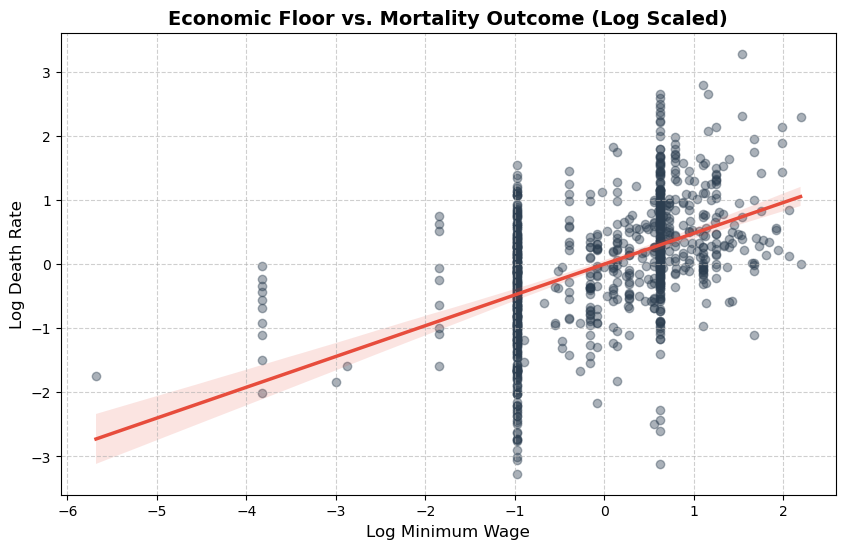

In [5]:
# plot of death vs min wage
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df, 
    x='log_min_wage', 
    y='log_death_rate', 
    scatter_kws={'alpha':0.4, 'color':'#2c3e50'}, 
    line_kws={'color':'#e74c3c', 'lw':2.5}
)

plt.title("Economic Floor vs. Mortality Outcome (Log Scaled)", fontsize=14, fontweight='bold')
plt.xlabel("Log Minimum Wage", fontsize=12)
plt.ylabel("Log Death Rate", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig(os.path.join(BASE_DIR, "resources", "death_rate_plots", "death_v_minwage.png"), dpi=300)
plt.show()

The regression plot visualizes the overall trend in our raw data: Higher minimum wages are generally associated with higher death rates. This contradicts our initial "Economic Protection" assumption.

In [6]:
# Isolate clusters
df_comp = df.loc[df.cluster_num.isin([0,1])].copy()

# Aggregate means
stats_comp = df_comp.groupby('cluster_lab').agg({
    'log_min_wage': 'mean',
    'log_death_rate': 'mean',
    'log_oxy': 'mean',
    'log_fent':'mean',
    'log_oxy_fent': 'mean'
}).rename(columns={
    'log_min_wage': 'Mean Min. Wage', 
    'log_death_rate': 'Mean Death Rate',
    'log_oxy': 'Mean Oxy Supply',
    'log_fent':'Mean Fentanyl Supply',
    'log_oxy_fent': 'Mean Oxy + Fent Supply'
})

# Calculate differences between clusters
mod_mask = stats_comp.index.str.contains('Moderate')
high_mask = stats_comp.index.str.contains('Prescription')

# Magnitudes (High Risk - Moderate Risk)
wage_gap = stats_comp.loc[high_mask, 'Mean Min. Wage'].iloc[0] - stats_comp.loc[mod_mask, 'Mean Min. Wage'].iloc[0]
death_gap = stats_comp.loc[high_mask, 'Mean Death Rate'].iloc[0] - stats_comp.loc[mod_mask, 'Mean Death Rate'].iloc[0]
oxy_gap = stats_comp.loc[high_mask, 'Mean Oxy Supply'].iloc[0] - stats_comp.loc[mod_mask, 'Mean Oxy Supply'].iloc[0]
fent_gap = stats_comp.loc[high_mask, 'Mean Fentanyl Supply'].iloc[0] - stats_comp.loc[mod_mask, 'Mean Fentanyl Supply'].iloc[0]
oxy_fent_gap = stats_comp.loc[high_mask, 'Mean Oxy + Fent Supply'].iloc[0] - stats_comp.loc[mod_mask, 'Mean Oxy + Fent Supply'].iloc[0]

# Percentages (Relative to the 'Moderate' Baseline)
wage_gap_pct = wage_gap / stats_comp.loc[mod_mask, 'Mean Min. Wage'].iloc[0]
death_gap_pct = death_gap / stats_comp.loc[mod_mask, 'Mean Death Rate'].iloc[0]
oxy_gap_pct = oxy_gap / stats_comp.loc[mod_mask, 'Mean Oxy Supply'].iloc[0]
fent_gap_pct = fent_gap / stats_comp.loc[mod_mask, 'Mean Fentanyl Supply'].iloc[0] # Fixed
oxy_fent_gap_pct = oxy_fent_gap / stats_comp.loc[mod_mask, 'Mean Oxy + Fent Supply'].iloc[0] # Fixed

# Adding rows to the stats_comp dataframe
stats_comp.loc['Difference (Magnitude)'] = [wage_gap, death_gap, oxy_gap, fent_gap, oxy_fent_gap]
stats_comp.loc['Difference (%)'] = [wage_gap_pct, death_gap_pct, oxy_gap_pct, fent_gap_pct, oxy_fent_gap_pct]

# Create a mask to only apply % logic to the first two columns
cols_to_pct = ['Mean Min. Wage', 'Mean Death Rate']

# In your final row assignment, you can do this:
stats_comp.loc['Difference (%)', cols_to_pct] = [wage_gap_pct, death_gap_pct]
# Leave the supply % cells as NaN or "-"
stats_comp.loc['Difference (%)', ['Mean Oxy Supply', 'Mean Fentanyl Supply', 'Mean Oxy + Fent Supply']] = np.nan

# Reorder cols
stats_comp = stats_comp[['Mean Min. Wage', 'Mean Death Rate', 'Mean Oxy Supply', 'Mean Fentanyl Supply',
                         'Mean Oxy + Fent Supply']]
stats_comp = round(stats_comp,4)

# Transpose, add Index and Column Labels
stats_comp = stats_comp.T
stats_comp.columns.name = "Cluster Label"
stats_comp.index.name = "Metric (Log-Scaled)"

# Fill NAs
stats_comp = stats_comp.fillna("-")

# Save comparison dataframe
stats_comp.to_csv(os.path.join(BASE_DIR, "resources", "death_rate_tables", "high-mod-wage-death-supply-comp.csv"))

# Output the formatted dataframe
print("Comparison Table:")
display(stats_comp)

Comparison Table:


Cluster Label,High Risk (Prescription-Driven),Moderate Risk,Difference (Magnitude),Difference (%)
Metric (Log-Scaled),,,,
Mean Min. Wage,0.7864,0.6866,0.0998,0.1453
Mean Death Rate,0.4759,0.2610,0.2149,0.8232
Mean Oxy Supply,0.6867,-0.1138,0.8005,-
Mean Fentanyl Supply,3.3926,-0.1204,3.5130,-
Mean Oxy + Fent Supply,1.5569,-0.1030,1.6599,-


Compared to the Moderate Risk cluster, the High Risk cluster actually has $14.5\%$ higher average minimum wages, an $82.3\%$ higher average death rate, and a higher than average drug supply across the board. Particularly of note is the massive oversupply of Fentanyl: $+3.51$ standard deviations higher than than the Moderate Risk cluster.

We thus posit that in states with extreme opioid availability, the "Economic Protection" offered by higher wages is overwhelmed by the influence of drug supply.

*Caveat:* Percentage differences for log-scaled variables represent relative shifts in log-space units, not raw value percentages.

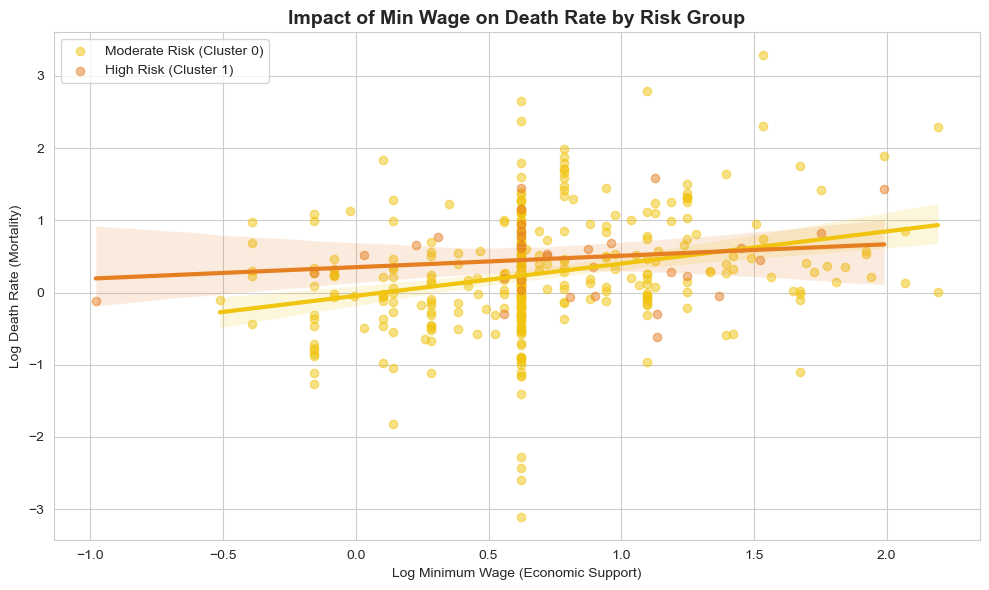

In [7]:
# Correlation between wages and death rate by cluster
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Regression - Is Wage Working as a Buffer?
sns.regplot(
    data=df_comp[df_comp['cluster_num'] == 0], 
    x='log_min_wage', y='log_death_rate', 
    color=color_discrete_map["Moderate Risk"], label='Moderate Risk (Cluster 0)',
    scatter_kws={'alpha':0.5}, line_kws={'lw':3}
)
sns.regplot(
    data=df_comp[df_comp['cluster_num'] == 1], 
    x='log_min_wage', y='log_death_rate', 
    color=color_discrete_map['High Risk (Prescription-Driven)'], label='High Risk (Cluster 1)',
    scatter_kws={'alpha':0.5}, line_kws={'lw':3}
)

plt.title("Impact of Min Wage on Death Rate by Risk Group", fontsize=14, fontweight='bold')
plt.xlabel("Log Minimum Wage (Economic Support)")
plt.ylabel("Log Death Rate (Mortality)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "resources", "death_rate_plots", "minwage_death_by_cluster.png"), dpi=300)
plt.show()

This plot further emphasizes the low correlation of minimum wage with mortality.

**Incorporating the Influence of Drug Supply**

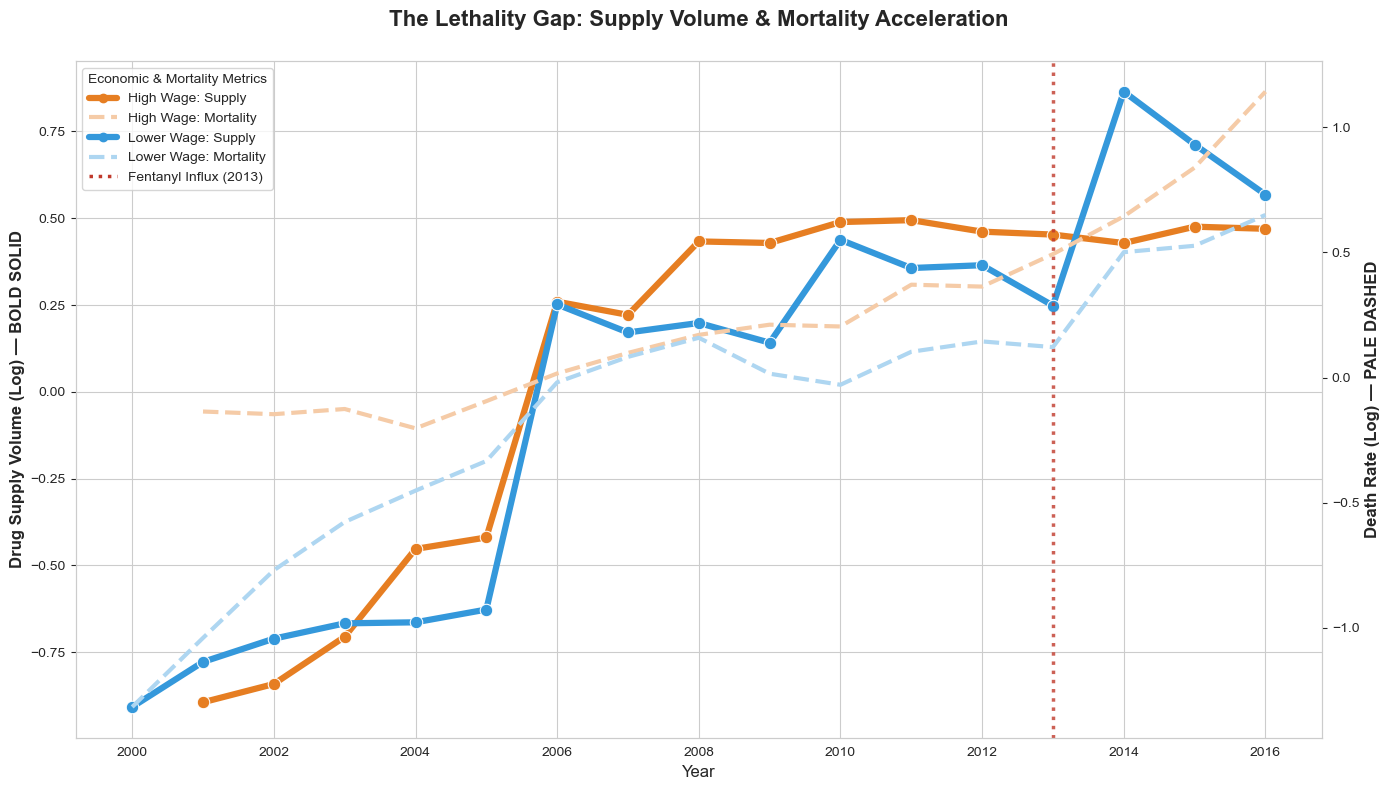

In [8]:
# Plotting Drug Supply and Mortality over Time

# Using median split to handle evolving economic standards
median_wage = df['log_min_wage'].median()
df['wage_category'] = np.where(df['log_min_wage'] >= median_wage, 'Higher Wage States', 'Lower Wage States')

# color palette: dark for supply, pale for death rate
colors_solid = {'Higher Wage States': '#e67e22', 'Lower Wage States': '#3498db'}
colors_pale = {'Higher Wage States': '#f5cba7', 'Lower Wage States': '#aed6f1'}

# plotting
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid") # Keeps gridlines for the Primary Axis (Supply)
ax1 = plt.gca() 
ax2 = ax1.twinx()

# remove gridlines for secondary axis
ax2.grid(False)

# drug supply
for category, color in colors_solid.items():
    subset = df[df['wage_category'] == category]
    sns.lineplot(
        data=subset, x='year', y='log_oxy_fent', 
        color=color, linewidth=4.5, marker='o', markersize=9, 
        errorbar=None, ax=ax1, label=f"{category} (Supply)"
    )

# death rate
for category, color in colors_pale.items():
    subset = df[df['wage_category'] == category]
    sns.lineplot(
        data=subset, x='year', y='log_death_rate', 
        color=color, linewidth=3, linestyle='--', 
        errorbar=None, ax=ax2, label=f"{category} (Mortality)"
    )

# fentanyl spike reference
ax1.axvline(x=fent_spike_year, color='#c0392b', linestyle=':', linewidth=2.5, alpha=0.8)

# labels
ax1.set_ylabel("Drug Supply Volume (Log) — BOLD SOLID", fontsize=12, fontweight='bold')
ax2.set_ylabel("Death Rate (Log) — PALE DASHED", fontsize=12, fontweight='bold')
ax1.set_xlabel("Year", fontsize=12)

# custom legend
legend_elements = [
    Line2D([0], [0], color=colors_solid['Higher Wage States'], lw=4.5, marker='o', label='High Wage: Supply'),
    Line2D([0], [0], color=colors_pale['Higher Wage States'], lw=3, ls='--', label='High Wage: Mortality'),
    Line2D([0], [0], color=colors_solid['Lower Wage States'], lw=4.5, marker='o', label='Lower Wage: Supply'),
    Line2D([0], [0], color=colors_pale['Lower Wage States'], lw=3, ls='--', label='Lower Wage: Mortality'),
    Line2D([0], [0], color='#c0392b', ls=':', lw=2.5, label='Fentanyl Influx (2013)')
]
ax1.legend(handles=legend_elements, loc='upper left', frameon=True, fontsize=10, title="Economic & Mortality Metrics")

if ax2.get_legend(): ax2.get_legend().remove()

plt.title("The Lethality Gap: Supply Volume & Mortality Acceleration", fontsize=16, fontweight='bold', pad=25)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "resources", "death_rate_plots", "lethality_gap.png"))
plt.show()

This plot demonstrates that for most of the study period, states with higher minimum wages had higher drug supply *and* higher mortality rates than states with lower minimum wages. This further confirms that "Economic Protections" matter less than the overall supply of Oxycodone and Fentanyl. The gap between supply and mortality is also much more pronounced for high wage states in the early period (2000-2005).

Interestingly, the drug supply for states with low minimum wages spiked higher than the supply for high minimum wage states in 2013/2014 (Fentanyl influx) and stayed higher until the end of the study period (2016). However, during this time the drug supply for high minimum wage states stayed consistent while mortality rates for these states continued to climb. Mortality rates for low minimum wage states also climbed, but to a lesser degree and never exceeding mortality for high min. wage states.

We proceed by building (rudimentary) regression models to quantify the varying impacts of Minimum Wage and Drug Supply on Death Rate.

In [9]:
# Build Models
# 'Naive Model', only looks at minimum wage
model_naive = smf.ols('log_death_rate ~ log_min_wage', data=df).fit()
wage_coef_naive = model_naive.params['log_min_wage']
r2_naive = model_naive.rsquared

# 'Controlled Model', accounts for oxy and fent
model_controlled = smf.ols('log_death_rate ~ log_min_wage + log_fent + log_oxy', data=df).fit()
wage_coef_controlled = model_controlled.params['log_min_wage']
fent_coef_controlled = model_controlled.params['log_fent']
oxy_coef_controlled = model_controlled.params['log_oxy']
r2_controlled = model_controlled.rsquared

# 'Interactive Model', 
model_interact = smf.ols('log_death_rate ~ log_fent + log_oxy + log_min_wage*log_oxy_fent', data=df).fit()
wage_coef_interact = model_interact.params['log_min_wage']
fent_coef_interact = model_interact.params['log_fent']
oxy_coef_interact = model_interact.params['log_oxy']
drug_coef_interact = model_interact.params['log_oxy_fent']
drug_wage_coef_interact = model_interact.params['log_min_wage:log_oxy_fent']
r2_interact = model_interact.rsquared

In [10]:
# Helper function to round and add asterisk for significance
def format_sig(val, p_val, alpha=0.05):
    if val is None or val == '-' or np.isnan(val):
        return '-'
    
    formatted_val = f"{val:.4f}"
    if p_val is not None and p_val < alpha:
        return f"{formatted_val}*"
    return formatted_val

# Comparison Dictionary, raw values
data = {
    "R-Squared": [model_naive.rsquared, model_controlled.rsquared, model_interact.rsquared],
    
    "WageCoef": [model_naive.params['log_min_wage'], 
                 model_controlled.params['log_min_wage'], 
                 model_interact.params['log_min_wage']],
    "Wage_P":   [model_naive.pvalues['log_min_wage'], 
                 model_controlled.pvalues['log_min_wage'], 
                 model_interact.pvalues['log_min_wage']],

    "FentCoef": [None, 
                 model_controlled.params['log_fent'], 
                 model_interact.params['log_fent']],
    "Fent_P":   [None, 
                 model_controlled.pvalues['log_fent'], 
                 model_interact.pvalues['log_fent']],

    "OxyCoef":  [None, 
                 model_controlled.params['log_oxy'], 
                 model_interact.params['log_oxy']],
    "Oxy_P":    [None, 
                 model_controlled.pvalues['log_oxy'], 
                 model_interact.pvalues['log_oxy']],

    "OxyFentCoef": [None, None, model_interact.params.get('log_oxy_fent')],
    "OxyFent_P":   [None, None, model_interact.pvalues.get('log_oxy_fent')],

    "DrugWageCoef": [None, None, model_interact.params.get('log_min_wage:log_oxy_fent')],
    "DrugWage_P":   [None, None, model_interact.pvalues.get('log_min_wage:log_oxy_fent')]
}

# Formatting
formatted_rows = []
for i in range(3): # For Naive, Controlled, Interactive
    row = {
        "R-Squared": f"{data['R-Squared'][i]:.4f}",
        "WageCoef": format_sig(data['WageCoef'][i], data['Wage_P'][i]),
        "FentCoef": format_sig(data['FentCoef'][i], data['Fent_P'][i]),
        "OxyCoef": format_sig(data['OxyCoef'][i], data['Oxy_P'][i]),
        "OxyFentCoef": format_sig(data['OxyFentCoef'][i], data['OxyFent_P'][i]),
        "OxyFent:WageCoef": format_sig(data['DrugWageCoef'][i], data['DrugWage_P'][i])
    }
    formatted_rows.append(row)

# Final comparison dataframe
model_comparison_df = pd.DataFrame(formatted_rows, index=['Naive', 'Controlled', 'Interactive'])

# Save table
model_comparison_df.to_csv(os.path.join(BASE_DIR, "resources", "death_rate_tables", "lmod_comp.csv"))

print("--- Final Model Comparison Table (Alpha = 0.05, Significance = *) ---")
display(model_comparison_df)

--- Final Model Comparison Table (Alpha = 0.05, Significance = *) ---


,R-Squared,WageCoef,FentCoef,OxyCoef,OxyFentCoef,OxyFent:WageCoef
Naive,0.2307,0.4803*,-,-,-,-
Controlled,0.3279,0.3192*,0.0519,0.3182*,-,-
Interactive,0.3288,0.3081*,0.0492,0.3250*,0.0042,-0.0375


**Naive Model:** Direct link between minimum wage and death rate.

This model suggests that Minimum Wage alone explains about 23% of the variance in death rates. Ignoring all other variables, the wage coefficient $(0.4803)$ indicates that as wages go up, drug deaths increase significantly. This overly simplistic model appears to confirms the contradiction we've been investigating; namely that higher wages lead to higher death rates.

**Controlled Model:** Also accounts for Oxycodone and Fentanyl Supply.

The 'Controlled' Model has a better R-Squared value than the Naive Model, implying that adding drug supply to the equation gives the model more predictive power. The wage coefficient drops from $0.4803$ to $0.3192$ and Oxycodone supply seems to be a slightly more significant driver of death rate with a coefficient of $0.3182$. However, its coefficient is nearly equal to that of wages suggesting that the economic environment is just as influential as the physical presence of opioids.

**Interactive Model:** Examines the interaction effect between drug supply and minimum wage.

The 'Interactive' Model fails to reveal a statistically significant interaction effect between minimum wage and overall drug supply. It has the best R-Squared value of all models, accounting for $\approx 33\%$ of the variability in death rate. This was achieved by slightly shifting predictive emphasis from minimum wage to the supply of Oxycodone.

**Interpretation:** Even accounting for drug supply and the interaction between suppy and wages, higher minimum wages consistently predict higher death rates. This suggests the paradox we've been investigating is a persistent structural feature of our data.

**Limitations**
- The models assume linear relationships between features and response that may not exist in the underlying data.
- Log-transformations were utilized to normalize skewed drug supply and mortality data, meaning coefficients represent relative shifts rather than raw unit changes.
- Drug supply here only refers to legitimate transactions reported to the DEA. We do not have solid data on the illicit marker supply, which could completely change the results of our analysis.
- The models relied only on the predictive features our K-Means Clustering analysis chose as the optimal features for clustering. Introducing a wider range of predictors could improve these models and lead to different conclusions.

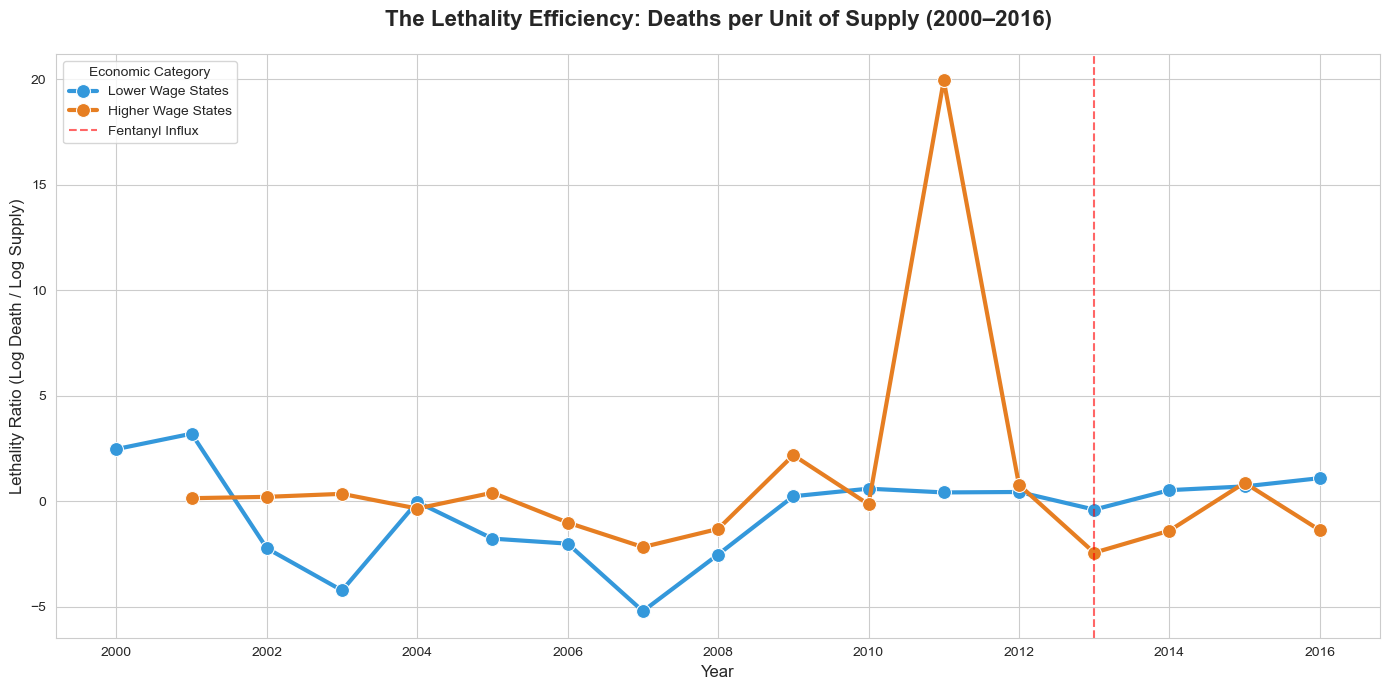

In [11]:
# calc ratio
df['lethality_ratio'] = df['log_death_rate'] / df['log_oxy_fent']

# plotting
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# color mapping
colors = {'Higher Wage States': '#e67e22', 'Lower Wage States': '#3498db'}

# plotting lethality over time
sns.lineplot(
    data=df, 
    x='year', 
    y='lethality_ratio', 
    hue='wage_category', 
    palette=colors,
    marker='o',
    markersize=10,
    linewidth=3,
    errorbar=None
)

# add line for fentanyl spike
plt.axvline(x=fent_spike_year, color='red', linestyle='--', alpha=0.6, label='Fentanyl Influx')

# Formatting
plt.title("The Lethality Efficiency: Deaths per Unit of Supply (2000–2016)", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Lethality Ratio (Log Death / Log Supply)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.legend(title="Economic Category", loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "resources", "death_rate_plots", "lethality_ratio.png"))
plt.show()

The consistency in lethality ratio (excl. 2011) for higher minimum wage states demonstrate that high-wage states consistently experience higher mortality across all levels of drug supply. This supports our theory that drugs are not more deadly in high-wage states than low-wage states. Instead something about the environmental conditions of high-wage states is driving mortality in those areas.

#### Conclusion

Our findings confirm a significant and persistent correlation between state-level minimum wages and opioid-related mortality. Initial observations suggested a "Lethality Gap" wherein higher-wage states appeared to experience an outsized increase in mortality due to increasing supplies. However, regression analysis on the full dataset indicates that the relationship is more structural.

Through three stages of modeling, the positive correlation between minimum wage and death rate remained statistically significant even when controlling for drug supply and potential interactive effects. This suggests the "wage paradox" may be driven by specific environmental factors in high-wage states rather than the byproduct of higher-wage states having higher drug supply.

Ultimately, drug supply remains the driver of the opioid crisis and the "Economic Protection" hypothesis is rejected. Over 2000 - 2016, higher nominal wages correlate with increased mortality; this phenomenom contradicts [traditional assumptions](https://odphp.health.gov/healthypeople/priority-areas/social-determinants-health) about economic prosperity and public health outcomes.

#### Recommendations for Future Research

Though this study found a persistent correlation between higher minimum wages and overdose mortality, the underlying mechanisms (the "why?") require further investigation. We recommend future research prioritize the following:

1. Cost of Living: Looking into actual customer purchasing power may help explain the mortality paradox. The increased cost of living in states with high minimum wages may actually exacerbate economic pains.

2. Population Density: Higher-wage states often have denser urban areas which may facilitate more effecieint drug distribution networks, thus a faster spread of highly dangerous synthetic opioids like Fentanyl.

3. Public Safety Net: It's possible that the mortality gap is widened by states where higher minimum wages do not correspond with increased investment in Substance Use Disorder treatment or harm-reduction infrastructure.

4. Realistic Wages of Overdose Victims: Right now, we don't know whether overdose victims are actually earning the minimum wage, or if wage levels act as a proxy for broader economic trends. If overdose deaths are concentrated among unhoused or undocumented communities, minimum wage would have little to no bearing on drug mortality.